### 0. Dataset Setup
Since `X` and `y` were not defined, we will generate a synthetic classification dataset so all subsequent tasks run smoothly.

In [ ]:
from sklearn.datasets import make_classification

# Generate synthetic data
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    random_state=42
)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 1. OOB Error Convergence & `max_features` Comparison

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


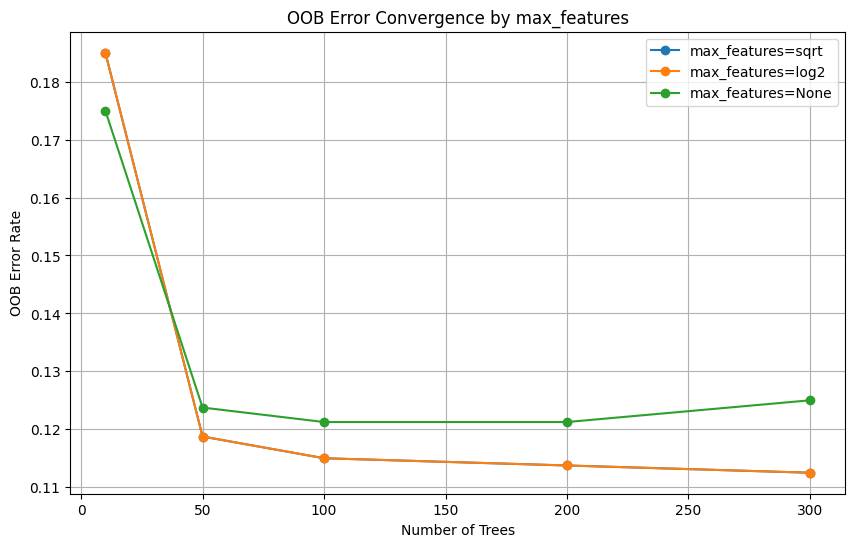

In [ ]:
n_trees = [10, 50, 100, 200, 300]
max_features_options = ['sqrt', 'log2', None]

plt.figure(figsize=(10, 6))

for max_feat in max_features_options:
    oob_scores = []
    for n in n_trees:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_features=max_feat,
            oob_score=True,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        # OOB Error = 1 - OOB Accuracy
        oob_scores.append(1 - rf.oob_score_)

    plt.plot(n_trees, oob_scores, marker='o', label=f'max_features={max_feat}')

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error Rate")
plt.title("OOB Error Convergence by max_features")
plt.legend()
plt.grid(True)
plt.show()

### 2. Manual Bagging Implementation
We will implement a custom bagging ensemble using `DecisionTreeClassifier` and bootstrap resampling.

In [ ]:
class ManualBaggingClassifier:
    def __init__(self, n_estimators=10, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        self.models = []
        np.random.seed(self.random_state)
        for i in range(self.n_estimators):
            # Bootstrap sample
            X_resampled, y_resampled = resample(
                X, y,
                replace=True,
                random_state=self.random_state + i
            )
            # Fit base estimator
            clf = DecisionTreeClassifier(random_state=self.random_state + i)
            clf.fit(X_resampled, y_resampled)
            self.models.append(clf)

    def predict(self, X):
        # Gather predictions from all estimators
        predictions = np.array([model.predict(X) for model in self.models])
        # Majority vote
        majority_votes = []
        for idx in range(X.shape[0]):
            votes = predictions[:, idx]
            majority_votes.append(np.bincount(votes).argmax())
        return np.array(majority_votes)

# Demo manual bagging
bagger = ManualBaggingClassifier(n_estimators=50, random_state=42)
bagger.fit(X_train, y_train)
bagging_preds = bagger.predict(X_val)
print("Manual Bagging Accuracy:", accuracy_score(y_val, bagging_preds))

Manual Bagging Accuracy: 0.845


### 3. Permutation Importance
Calculating feature importance using permutation testing on validation data.

/tmp/ipykernel_3718/65924172.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


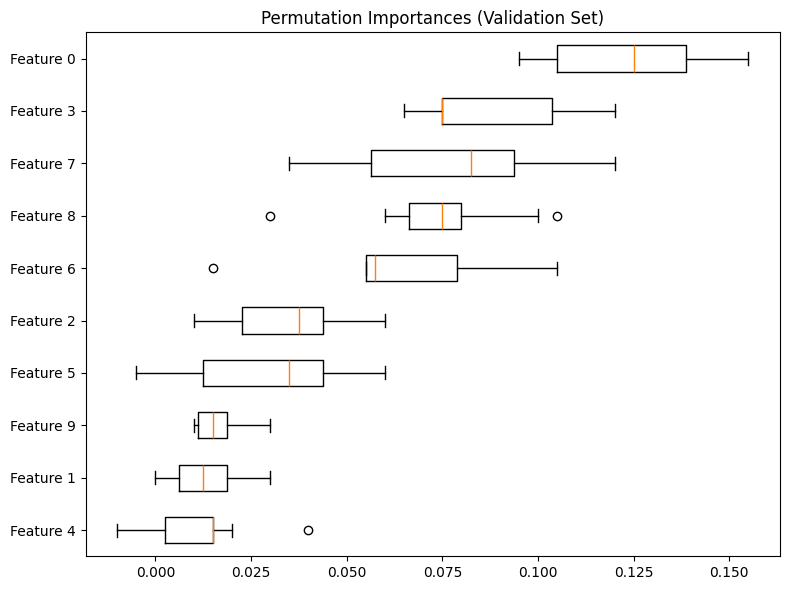

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

result = permutation_importance(
    rf_model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
)

sorted_importances_idx = result.importances_mean.argsort()

plt.figure(figsize=(8, 6))
plt.boxplot(
    result.importances[sorted_importances_idx].T,
    vert=False,
    labels=[f"Feature {i}" for i in sorted_importances_idx]
)
plt.title("Permutation Importances (Validation Set)")
plt.tight_layout()
plt.show()

### 4. Random Forest vs. Single Decision Tree Function
A function to evaluate and compare a Random Forest ensemble against a standalone Decision Tree.

In [ ]:
def compare_rf_vs_single_tree(X_train, X_val, y_train, y_val, n_estimators=100, max_depth=None, random_state=42):
    # 1. Single Decision Tree
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    dt.fit(X_train, y_train)
    dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
    dt_val_acc = accuracy_score(y_val, dt.predict(X_val))

    # 2. Random Forest
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
    rf_val_acc = accuracy_score(y_val, rf.predict(X_val))

    print("=== Performance Comparison ===")
    print(f"Single Decision Tree: Train Accuracy = {dt_train_acc:.4f} | Validation Accuracy = {dt_val_acc:.4f}")
    print(f"Random Forest ({n_estimators} trees): Train Accuracy = {rf_train_acc:.4f} | Validation Accuracy = {rf_val_acc:.4f}")

# Run comparison
compare_rf_vs_single_tree(X_train, X_val, y_train, y_val, n_estimators=100)

=== Performance Comparison ===
Single Decision Tree: Train Accuracy = 1.0000 | Validation Accuracy = 0.7300
Random Forest (100 trees): Train Accuracy = 1.0000 | Validation Accuracy = 0.8700


QUESTION 2


In [ ]:
import pandas as pd

def rf_vs_single_tree(X_train, y_train, X_val, y_val, n_estimators_list):
    # 1. Train and evaluate a Single Decision Tree once as a baseline
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)
    dt_val_acc = accuracy_score(y_val, dt.predict(X_val))

    results = []

    # 2. Iterate through n_estimators list for Random Forest
    for n in n_estimators_list:
        rf = RandomForestClassifier(
            n_estimators=n,
            oob_score=True,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        rf_val_acc = accuracy_score(y_val, rf.predict(X_val))
        oob_score = rf.oob_score_

        results.append({
            'n_estimators': n,
            'rf_val_accuracy': rf_val_acc,
            'rf_oob_accuracy': oob_score,
            'single_tree_val_accuracy': dt_val_acc
        })

    # Return results as a pandas DataFrame
    return pd.DataFrame(results)

In [ ]:
# Run and display the comparison DataFrame
estimators_list = [10, 50, 100, 200, 300]
df_comparison = rf_vs_single_tree(X_train, y_train, X_val, y_val, estimators_list)
display(df_comparison)

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
